### Carga de los Datos de Delitos Puerto Montt

In [13]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

In [12]:
!pip install scikit-learn matplotlib seaborn pandas numpy

In [14]:
# Cargar los datos desde el archivo CSV
# El separador es punto y coma (;) y el separador de miles es punto (.)
delitos = pd.read_csv("dat_final.csv", sep=';', thousands='.')
print(delitos.keys())
print(delitos)

Index(['DELITOS O FALTAS', 'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo',
       'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre',
       'Diciembre'],
      dtype='str')
                                    DELITOS O FALTAS  Enero  Febrero  Marzo  \
0                            Homicidios y femicidios      3        1      0   
1               Violaciones y otros delitos sexuales     22       26     28   
2                       Lesiones graves o gravísimas      9        8     10   
3                              Lesiones menos graves     13       15     12   
4                                     Lesiones leves     53       75     89   
5                                           Amenazas    232      223    256   
6                 Robos con violencia o intimidación     42       43     38   
7                                  Robo por sorpresa     18       19     23   
8                            Violencia intrafamiliar    253      230    261   
9                       

In [15]:
# Convertir a formato largo: cada fila = (delito, mes, cantidad)
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

delitos_long = delitos.melt(id_vars=['DELITOS O FALTAS'], value_vars=meses,
                             var_name='Mes', value_name='Cantidad')

mes_num = {mes: i+1 for i, mes in enumerate(meses)}
delitos_long['Mes_Num'] = delitos_long['Mes'].map(mes_num)
delitos_long.head()

,DELITOS O FALTAS,Mes,Cantidad,Mes_Num
0,Homicidios y femicidios,Enero,3,1
1,Violaciones y otros delitos sexuales,Enero,22,1
2,Lesiones graves o gravísimas,Enero,9,1
3,Lesiones menos graves,Enero,13,1
4,Lesiones leves,Enero,53,1


In [16]:
# Eliminar los espacios vacíos y nulos
delitos_long.isnull().sum()

DELITOS O FALTAS    0
Mes                 0
Cantidad            0
Mes_Num             0
dtype: int64

###Exploración de los Datos

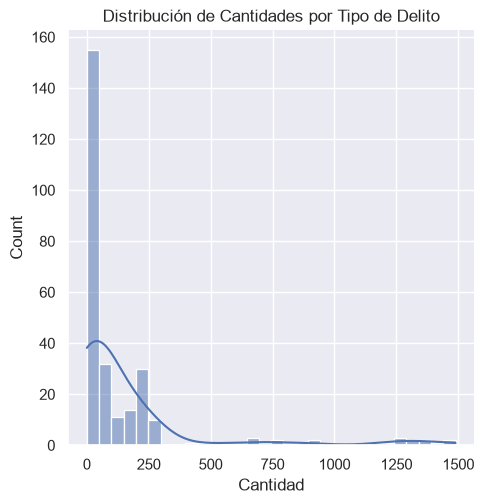

In [17]:
sns.set(rc = {'figure.figsize': (20,10)})
sns.displot(delitos_long['Cantidad'], bins=30, kde=True)
plt.title("Distribución de Cantidades por Tipo de Delito")
plt.show()

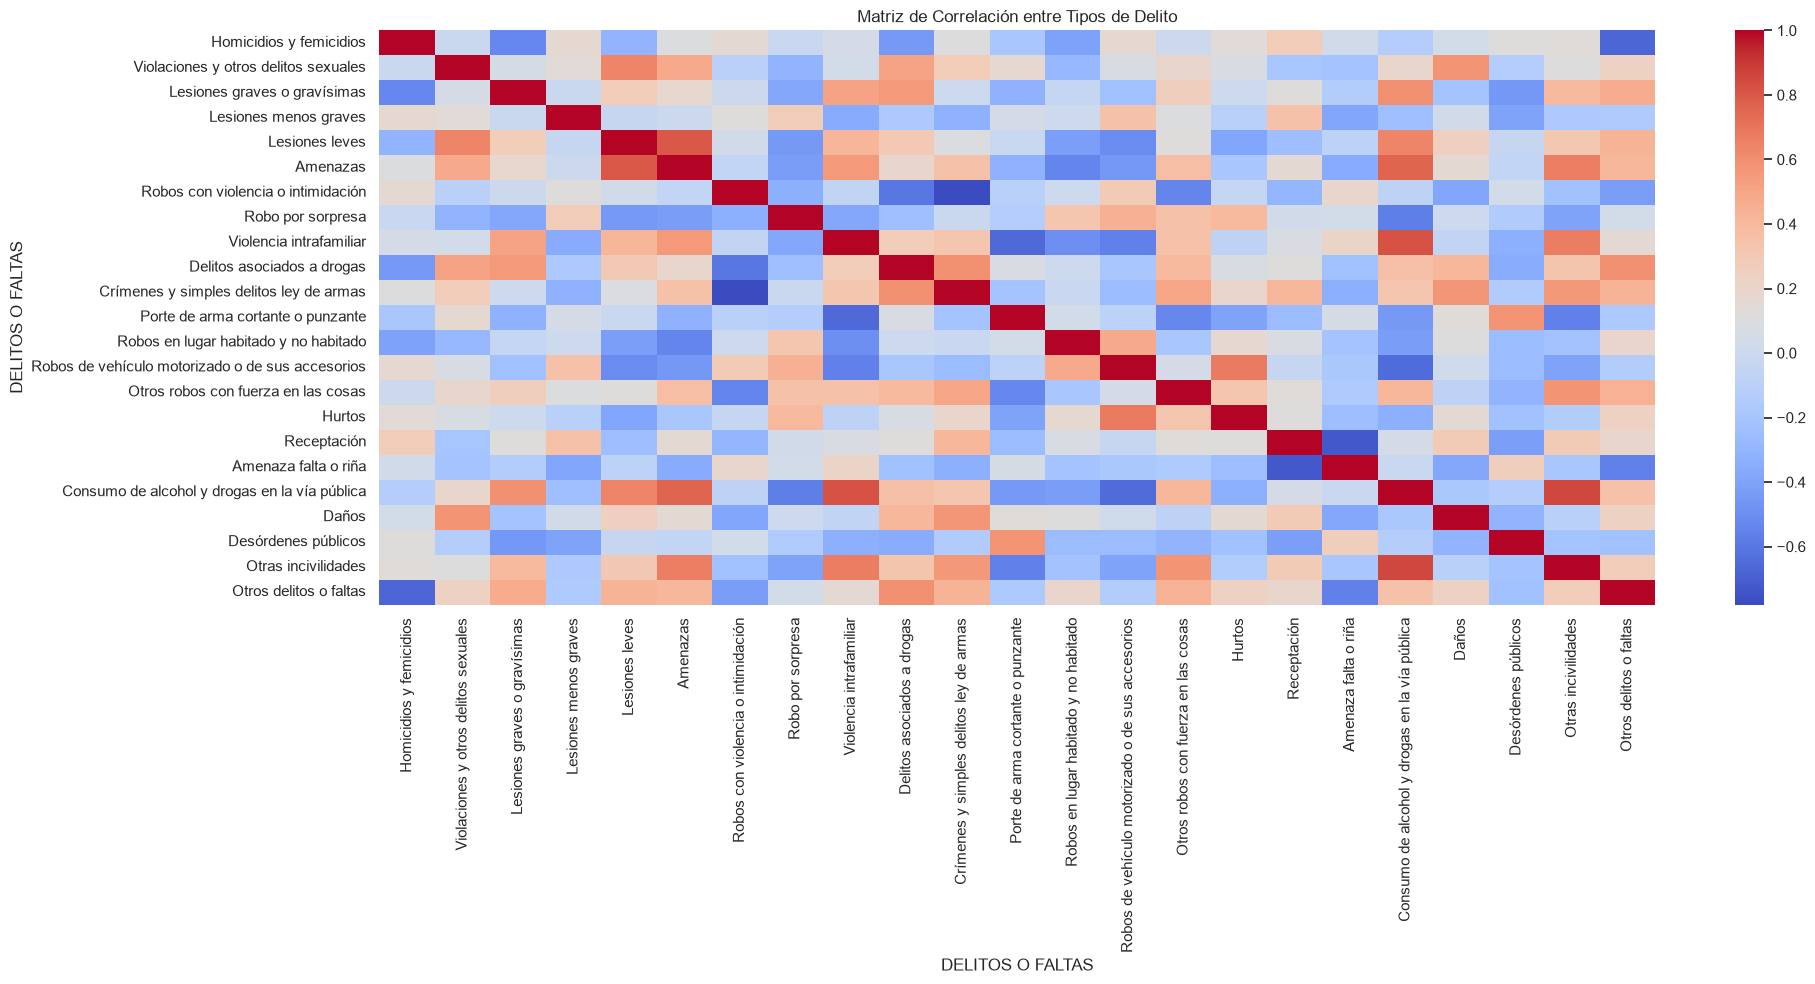

In [18]:
# Matriz de correlación entre meses (tendencia temporal)
pivot = delitos.set_index('DELITOS O FALTAS')[meses]
matriz_corr = pivot.T.corr().round(2)
sns.heatmap(data=matriz_corr, annot=False, cmap='coolwarm')
plt.title("Matriz de Correlación entre Tipos de Delito")
plt.tight_layout()
plt.show()

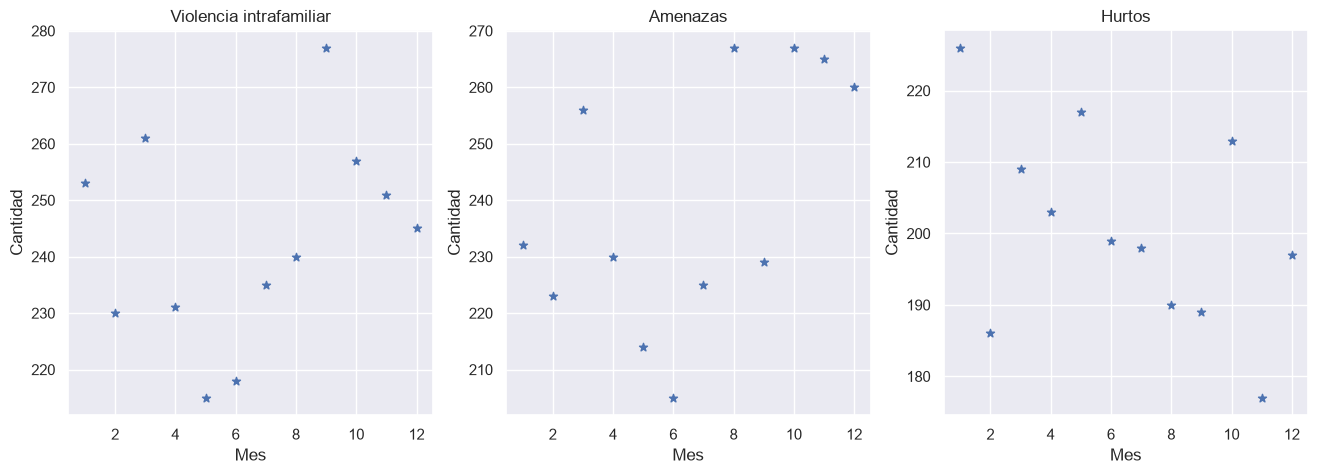

In [19]:
# Graficar evolución mensual de delitos seleccionados
plt.figure(figsize=(16, 5))

delitos_seleccionados = ['Violencia intrafamiliar', 'Amenazas', 'Hurtos']
objetivo = delitos_long['Mes_Num']

for i, delito in enumerate(delitos_seleccionados):
    plt.subplot(1, len(delitos_seleccionados), i+1)
    datos = delitos_long[delitos_long['DELITOS O FALTAS'] == delito]
    x = datos['Mes_Num']
    y = datos['Cantidad']
    plt.scatter(x, y, marker='*')
    plt.title(delito)
    plt.xlabel('Mes')
    plt.ylabel('Cantidad')

###Preprocesamiento de Datos

In [20]:
# Dividir los conjuntos en X (mes número) e Y (cantidad de delitos)
X = pd.DataFrame(np.c_[delitos_long['Mes_Num']], columns=['Mes_Num'])
y = delitos_long['Cantidad']

In [21]:
# Separar entre los conjuntos de entrenamiento y testeo
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

print("Entrenamiento: X = {}, y = {}".format(X_train.shape, y_train.shape))
print("Testeo: X = {}, y = {}".format(X_test.shape, y_test.shape))

Entrenamiento: X = (220, 1), y = (220,)
Testeo: X = (56, 1), y = (56,)


###Crear Modelo

In [22]:
# Creación del modelo de regresión Lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

modelo = LinearRegression()  # Hipótesis

In [23]:
# Entrenamiento
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[3.44]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Mes_Num']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,140.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [24]:
# Evaluación del Entrenamiento con el modelo

y_predicted = modelo.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_predicted))
r2 = r2_score(y_train, y_predicted)

print("Rendimiento del conjunto de Entrenamiento")
print("RMSE: {}".format(rmse))
print("R2: {}".format(r2))

Rendimiento del conjunto de Entrenamiento
RMSE: 308.441180057541
R2: 0.001507285989590934


In [25]:
# Evaluación del Test con el modelo

y_predicted = modelo.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_predicted))
r2 = r2_score(y_test, y_predicted)

print("Rendimiento del conjunto de Testeo")
print("RMSE: {}".format(rmse))
print("R2: {}".format(r2))

Rendimiento del conjunto de Testeo
RMSE: 231.06827033588974
R2: -0.049583979652382926


###Predicción del Siguiente Periodo

In [26]:
# Entrenar un modelo por tipo de delito y predecir el mes 13 (siguiente periodo)
mes_siguiente = pd.DataFrame([[13]], columns=['Mes_Num'])
predicciones = []

for delito in delitos['DELITOS O FALTAS']:
    datos_delito = delitos_long[delitos_long['DELITOS O FALTAS'] == delito]
    X_del = pd.DataFrame(datos_delito['Mes_Num'].values, columns=['Mes_Num'])
    y_del = datos_delito['Cantidad'].values

    modelo_del = LinearRegression()
    modelo_del.fit(X_del, y_del)
    pred = modelo_del.predict(mes_siguiente)[0]
    predicciones.append({'Delito': delito, 'Prediccion': round(pred, 2)})

predicciones_df = pd.DataFrame(predicciones).sort_values('Prediccion', ascending=False).reset_index(drop=True)
print(predicciones_df)

                                              Delito  Prediccion
0                             Otros delitos o faltas     1351.44
1      Consumo de alcohol y drogas en la vía pública      835.05
2                                           Amenazas      260.71
3                            Violencia intrafamiliar      251.73
4                                              Daños      226.59
5                                             Hurtos      188.42
6              Robos en lugar habitado y no habitado      143.89
7                                Otras incivilidades      104.14
8                                     Lesiones leves       90.64
9   Robos de vehículo motorizado o de sus accesorios       63.88
10           Crímenes y simples delitos ley de armas       44.92
11                        Delitos asociados a drogas       43.70
12              Violaciones y otros delitos sexuales       37.74
13                Robos con violencia o intimidación       37.70
14                 Porte 

In [27]:
# Los cinco delitos con mayor predicción para el siguiente mes
top5 = predicciones_df.head(5)
print("Top 5 Delitos con Mayor Predicción para el Siguiente Período:")
print(top5.to_string(index=False))

Top 5 Delitos con Mayor Predicción para el Siguiente Período:
                                       Delito  Prediccion
                       Otros delitos o faltas     1351.44
Consumo de alcohol y drogas en la vía pública      835.05
                                     Amenazas      260.71
                      Violencia intrafamiliar      251.73
                                        Daños      226.59


###Gráficas de Rendimiento

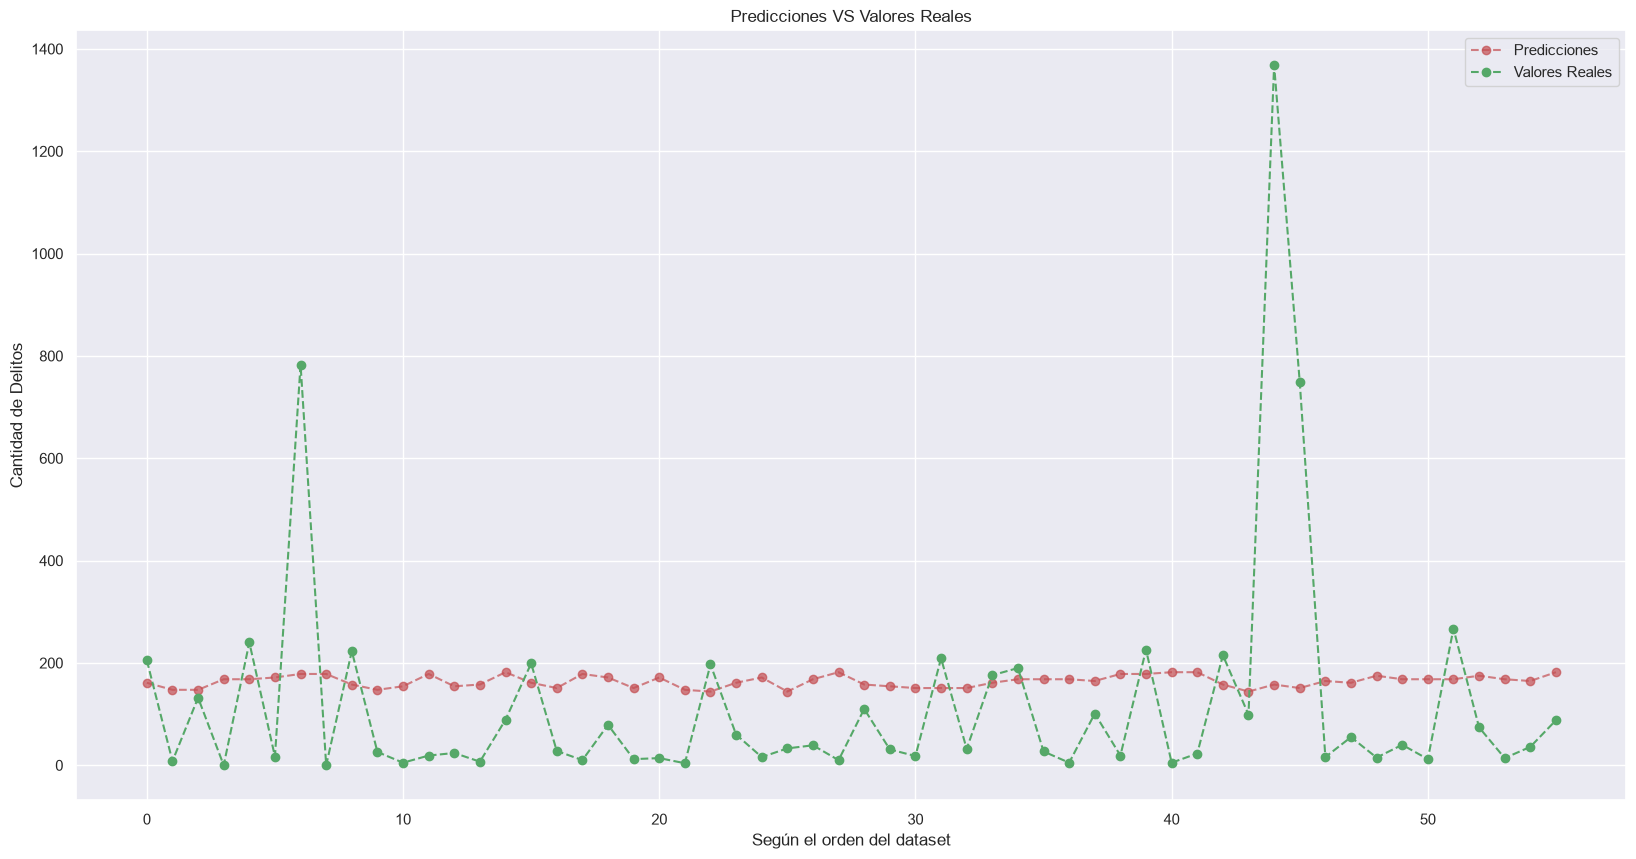

In [28]:
# Gráfica de rendimiento de las predicciones (test set)
y_predicted = modelo.predict(X_test)
eje_x = np.array(range(0, y_predicted.shape[0]))

plt.plot(eje_x, y_predicted, linestyle="--", marker="o", alpha=0.7, color="r", label="Predicciones")
plt.plot(eje_x, y_test.values, linestyle="--", marker="o", color="g", label="y_test")
plt.xlabel("Según el orden del dataset")
plt.ylabel("Cantidad de Delitos")
plt.legend(["Predicciones", "Valores Reales"])
plt.title("Predicciones VS Valores Reales")
plt.show()

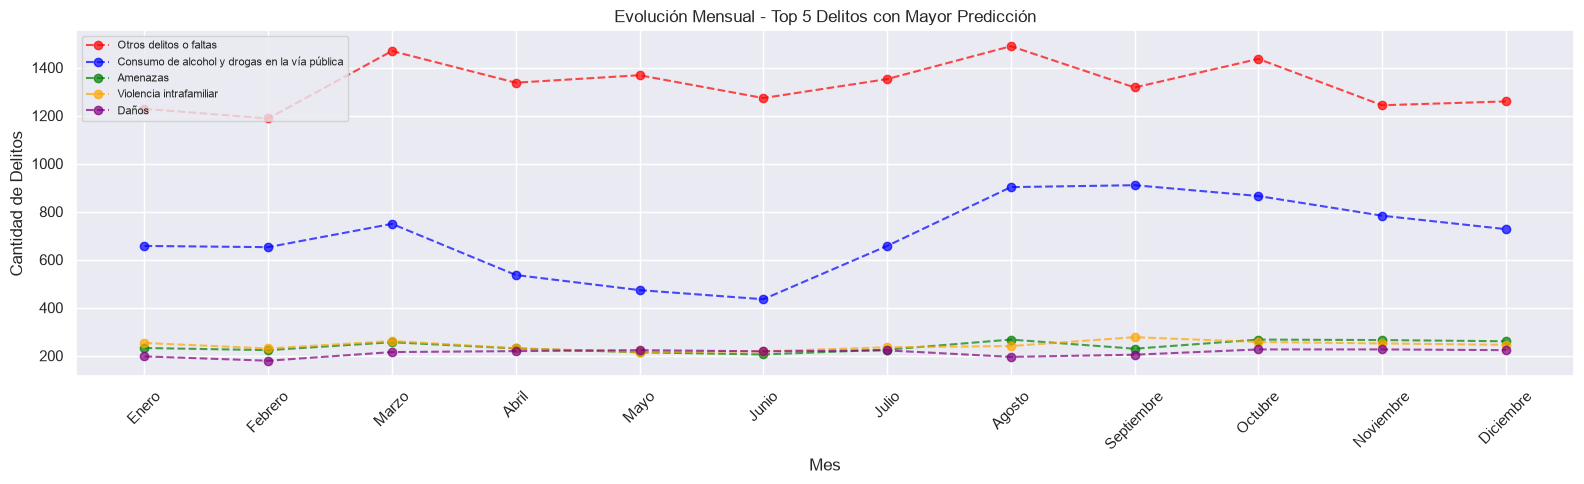

In [29]:
# Gráfica ordenada: Top 5 delitos predichos vs valores reales por mes
plt.figure(figsize=(16, 5))

colores = ['red', 'blue', 'green', 'orange', 'purple']

for i, row in top5.iterrows():
    delito = row['Delito']
    datos = delitos_long[delitos_long['DELITOS O FALTAS'] == delito].sort_values('Mes_Num')
    plt.plot(datos['Mes_Num'], datos['Cantidad'], linestyle="--", marker="o",
             color=colores[list(top5.index).index(i)], alpha=0.7, label=delito)

plt.title("Evolución Mensual - Top 5 Delitos con Mayor Predicción")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Delitos")
plt.xticks(range(1, 13), meses, rotation=45)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

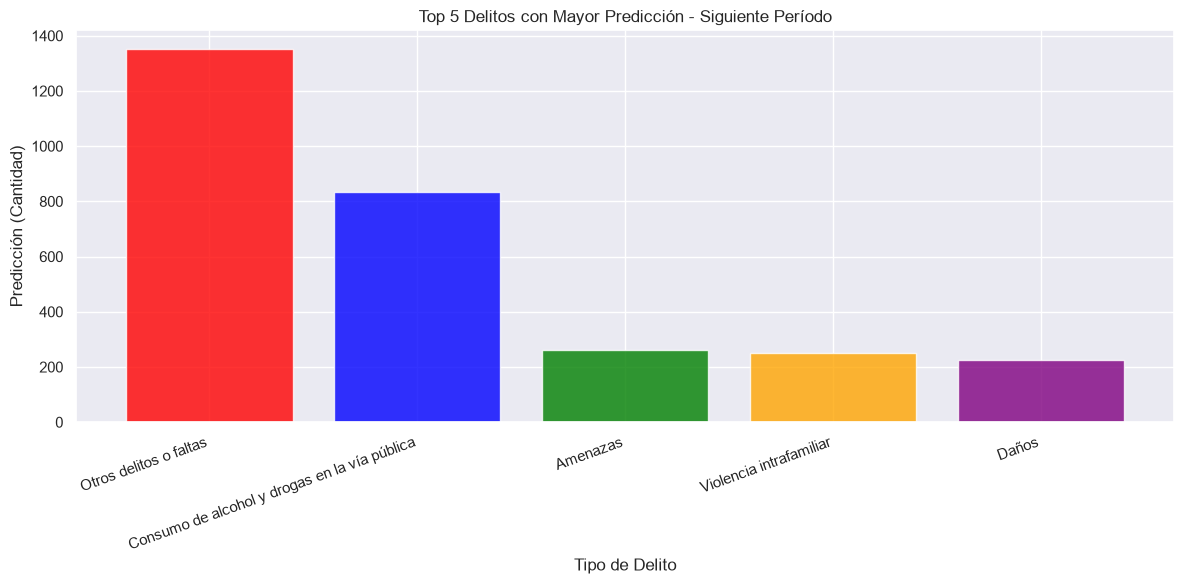

In [30]:
# Gráfica de barras: Top 5 delitos con mayor predicción
plt.figure(figsize=(12, 6))
plt.bar(top5['Delito'], top5['Prediccion'], color=['red', 'blue', 'green', 'orange', 'purple'], alpha=0.8)
plt.title("Top 5 Delitos con Mayor Predicción - Siguiente Período")
plt.xlabel("Tipo de Delito")
plt.ylabel("Predicción (Cantidad)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

###Comparando con otros modelos (Hipótesis)

In [31]:
def probar_modelo(tipo_hipotesis, X_train, y_train, X_test, y_test):
    modelo = tipo_hipotesis
    modelo.fit(X_train, y_train)

    # Evaluación del Entrenamiento con el modelo
    y_train_predicted = modelo.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_train, y_train_predicted))
    r2 = r2_score(y_train, y_train_predicted)

    print("Rendimiento del conjunto de Entrenamiento")
    print("RMSE: {}".format(rmse))
    print("R2: {}".format(r2))

    # Evaluación del Test con el modelo
    y_test_predicted = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_predicted))
    r2 = r2_score(y_test, y_test_predicted)

    print("Rendimiento del conjunto de Testeo")
    print("RMSE: {}".format(rmse))
    print("R2: {}".format(r2))

    # Gráfica de rendimiento de las predicciones
    eje_x = np.array(range(0, y_test_predicted.shape[0]))

    plt.plot(eje_x, y_test_predicted, linestyle="--", marker="o", alpha=0.7, color="r", label="Predicciones")
    plt.plot(eje_x, y_test.values, linestyle="--", marker="o", color="g", label="y_test")
    plt.xlabel("Según el orden del dataset")
    plt.ylabel("Cantidad de Delitos")
    plt.legend(["Predicciones", "Valores Reales"])
    plt.show()

    # Gráfica ordenada por el modelo
    modelo_desordenado = pd.DataFrame(np.c_[X_test, y_test_predicted], columns=['Mes_Num', 'Cantidad_'])
    modelo_ordenado = modelo_desordenado.sort_values(by='Mes_Num', ascending=True)

    plt.figure(figsize=(16, 5))
    plt.plot(modelo_ordenado['Mes_Num'], modelo_ordenado['Cantidad_'],
             linestyle="--", marker="o", alpha=0.7, color="r", label="Predicciones")
    plt.scatter(X_test, y_test, marker="o")
    plt.title("Predicciones del Modelo")
    plt.xlabel("Mes")
    plt.ylabel("Cantidad de Delitos")
    plt.show()

Probando el Modelo Lasso
Rendimiento del conjunto de Entrenamiento
RMSE: 308.44131382910115
R2: 0.001506419892806421
Rendimiento del conjunto de Testeo
RMSE: 231.02706756001388
R2: -0.049209701368793324


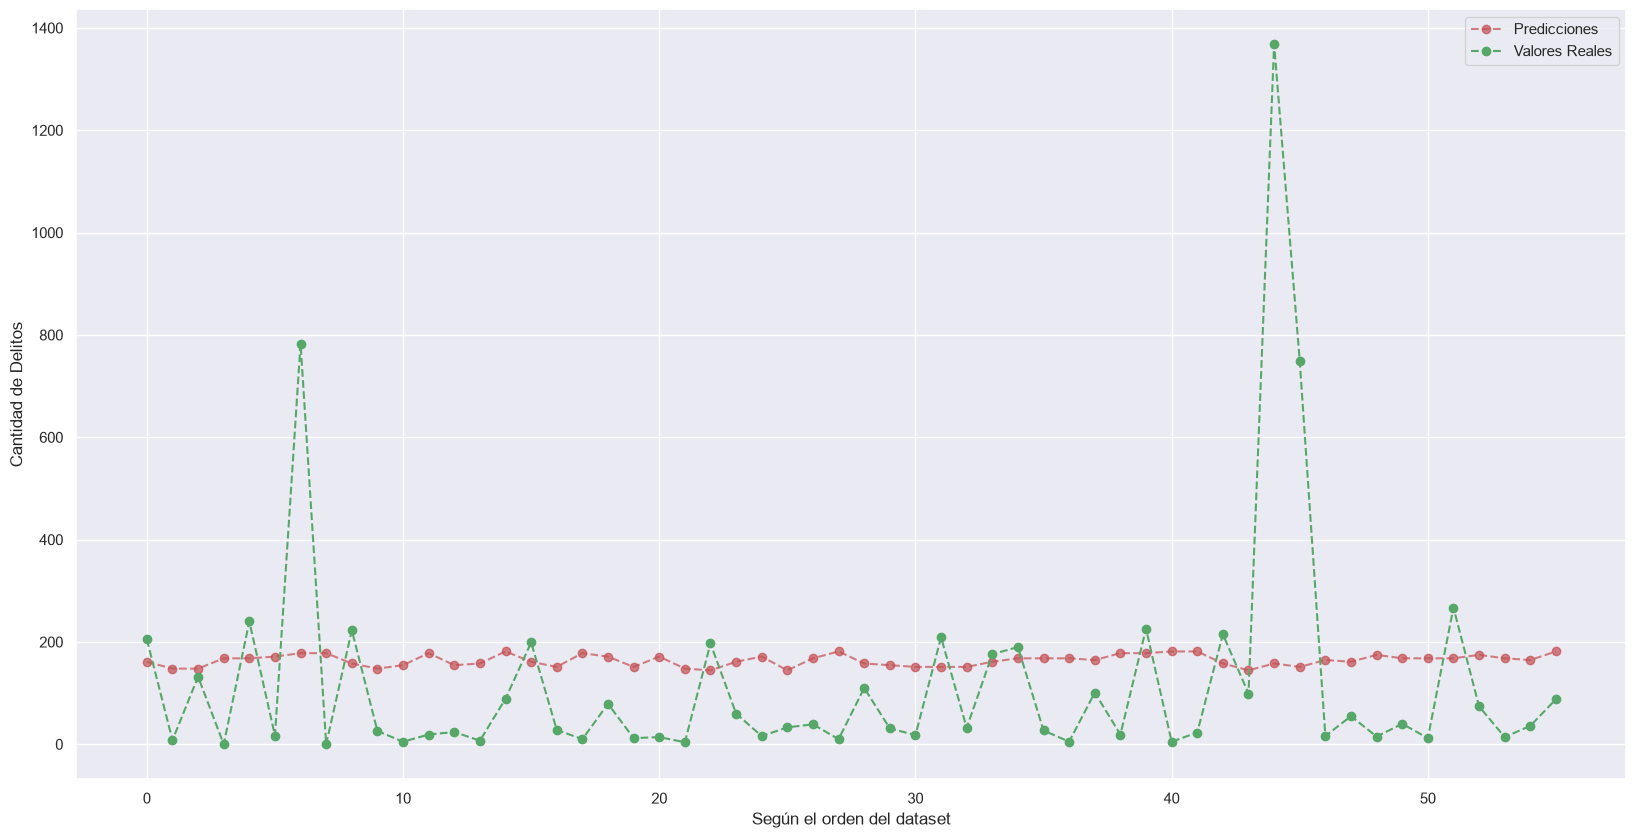

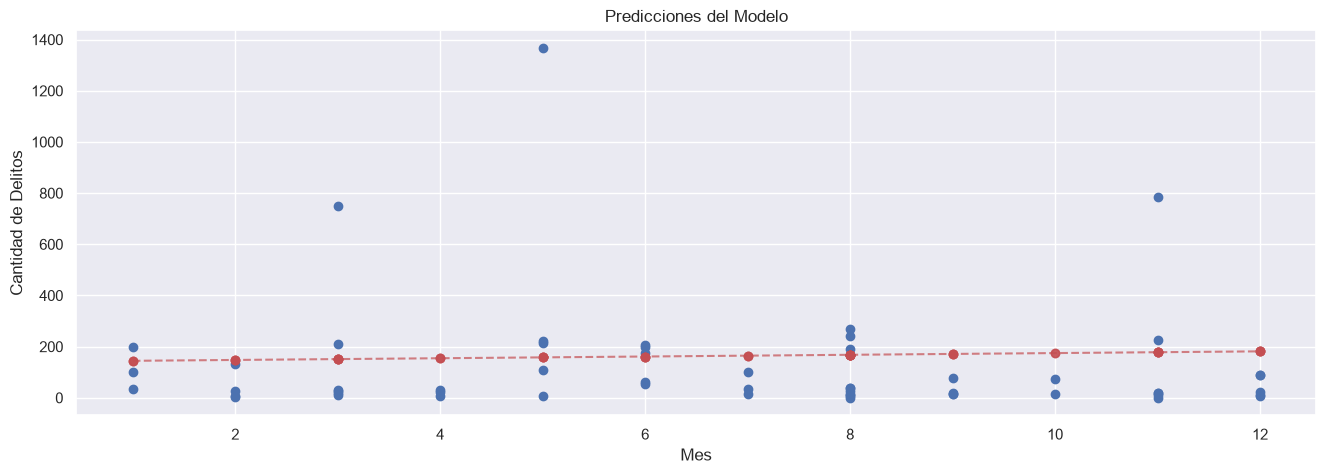

In [32]:
from sklearn.linear_model import Lasso

print("Probando el Modelo Lasso")
probar_modelo(Lasso(), X_train, y_train, X_test, y_test)

Probando el ARD
Rendimiento del conjunto de Entrenamiento
RMSE: 308.6737609805622
R2: 8.858780238263364e-07
Rendimiento del conjunto de Testeo
RMSE: 229.62442749947004
R2: -0.036508193257349


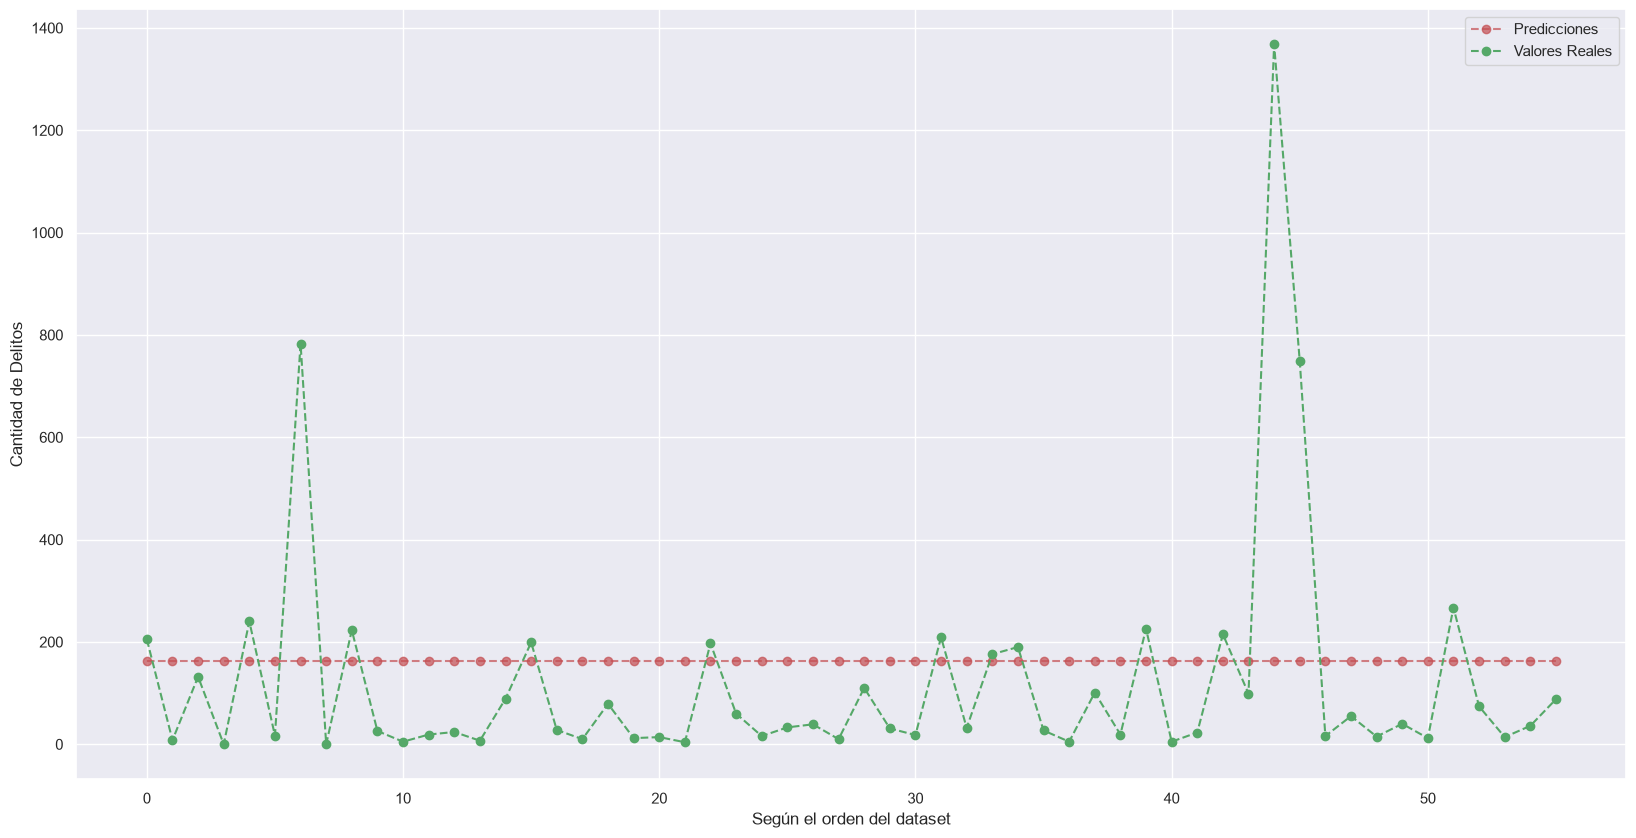

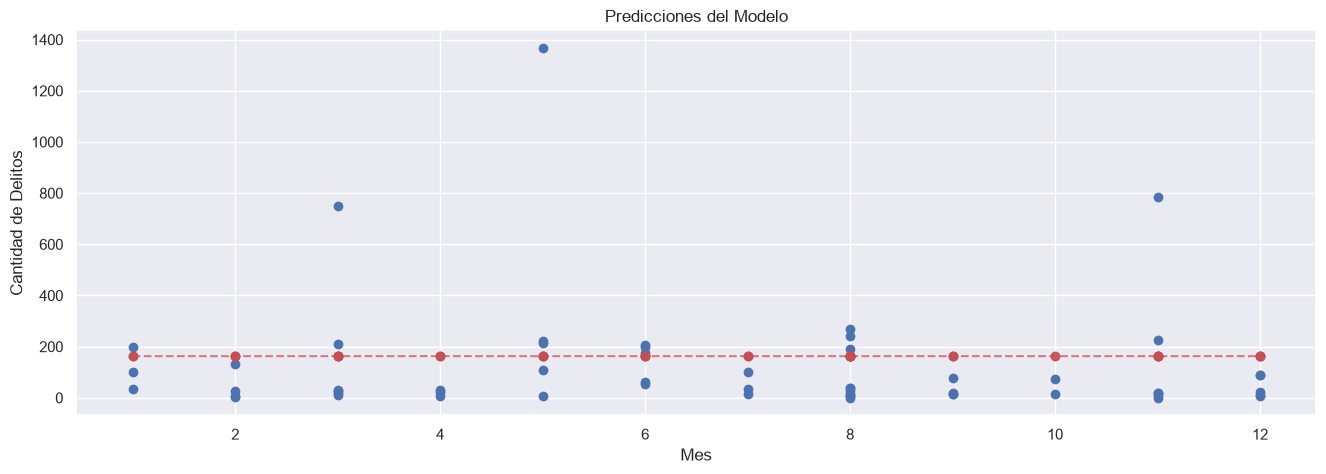

In [33]:
from sklearn.linear_model import ARDRegression

print("Probando el ARD")
probar_modelo(ARDRegression(), X_train, y_train, X_test, y_test)

Probando el SVM
Rendimiento del conjunto de Entrenamiento
RMSE: 332.69654568938194
R2: -0.16170744222603495
Rendimiento del conjunto de Testeo
RMSE: 239.996565498995
R2: -0.13226118567913292


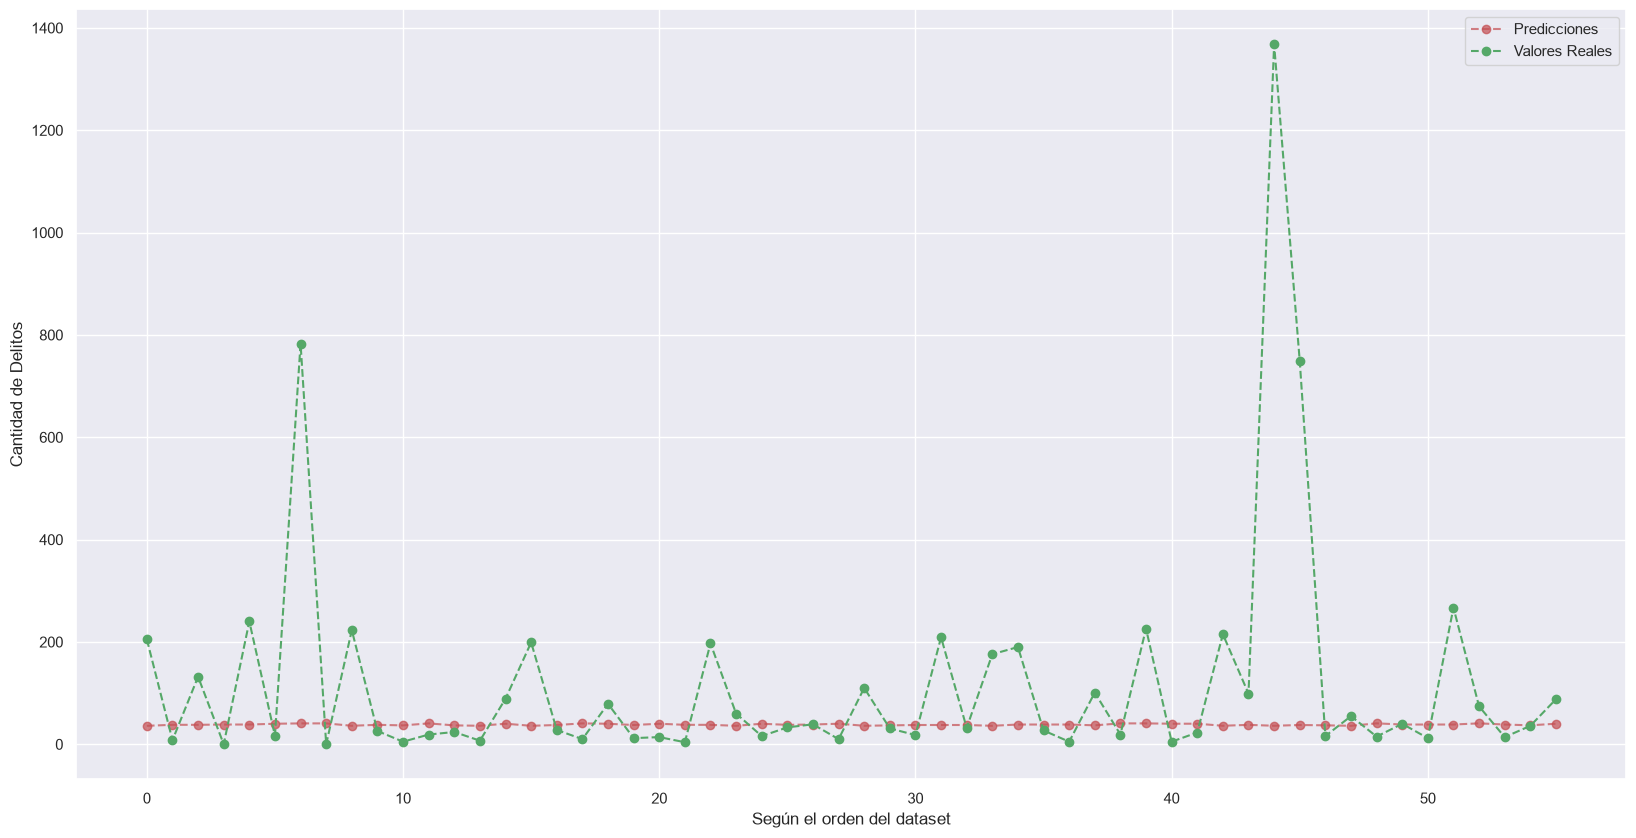

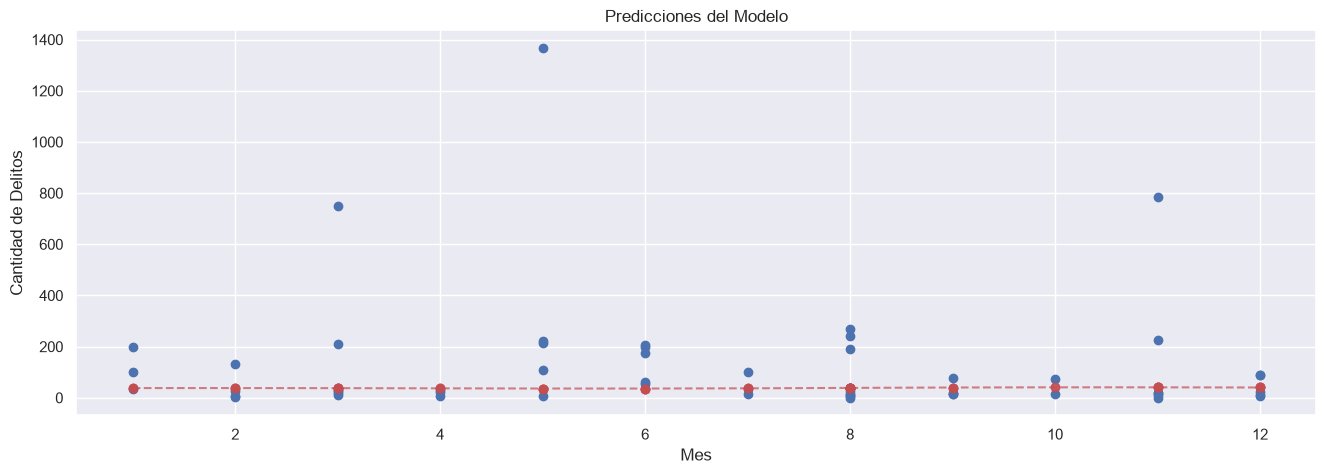

In [34]:
from sklearn.svm import SVR

print("Probando el SVM")
probar_modelo(SVR(), X_train, y_train, X_test, y_test)

Probando el DTR
Rendimiento del conjunto de Entrenamiento
RMSE: 306.8308882474403
R2: 0.011905816538096858
Rendimiento del conjunto de Testeo
RMSE: 247.14889168320116
R2: -0.20075360954717802


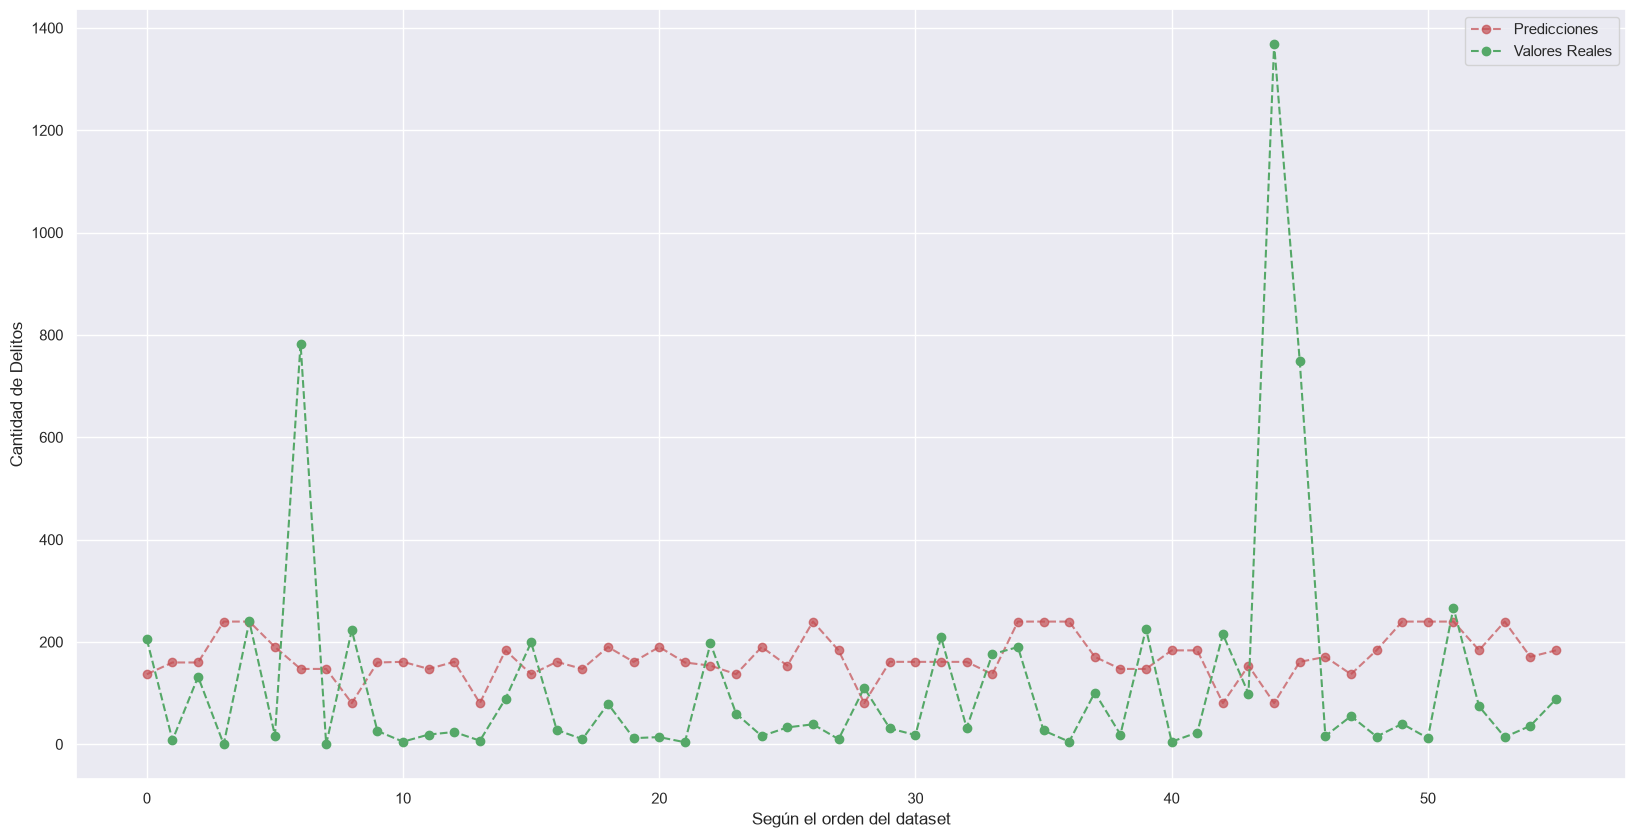

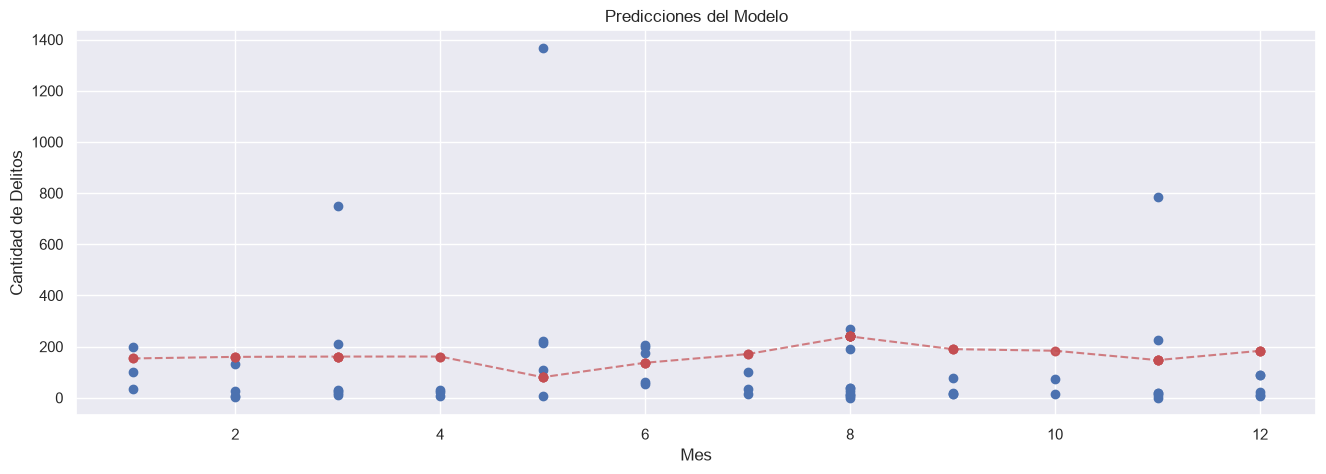

In [35]:
from sklearn.tree import DecisionTreeRegressor

print("Probando el DTR")
probar_modelo(DecisionTreeRegressor(), X_train, y_train, X_test, y_test)

Probando el Modelo KNN
Rendimiento del conjunto de Entrenamiento
RMSE: 326.93996223938564
R2: -0.12185364775208263
Rendimiento del conjunto de Testeo
RMSE: 255.84116445281325
R2: -0.28670033048485744


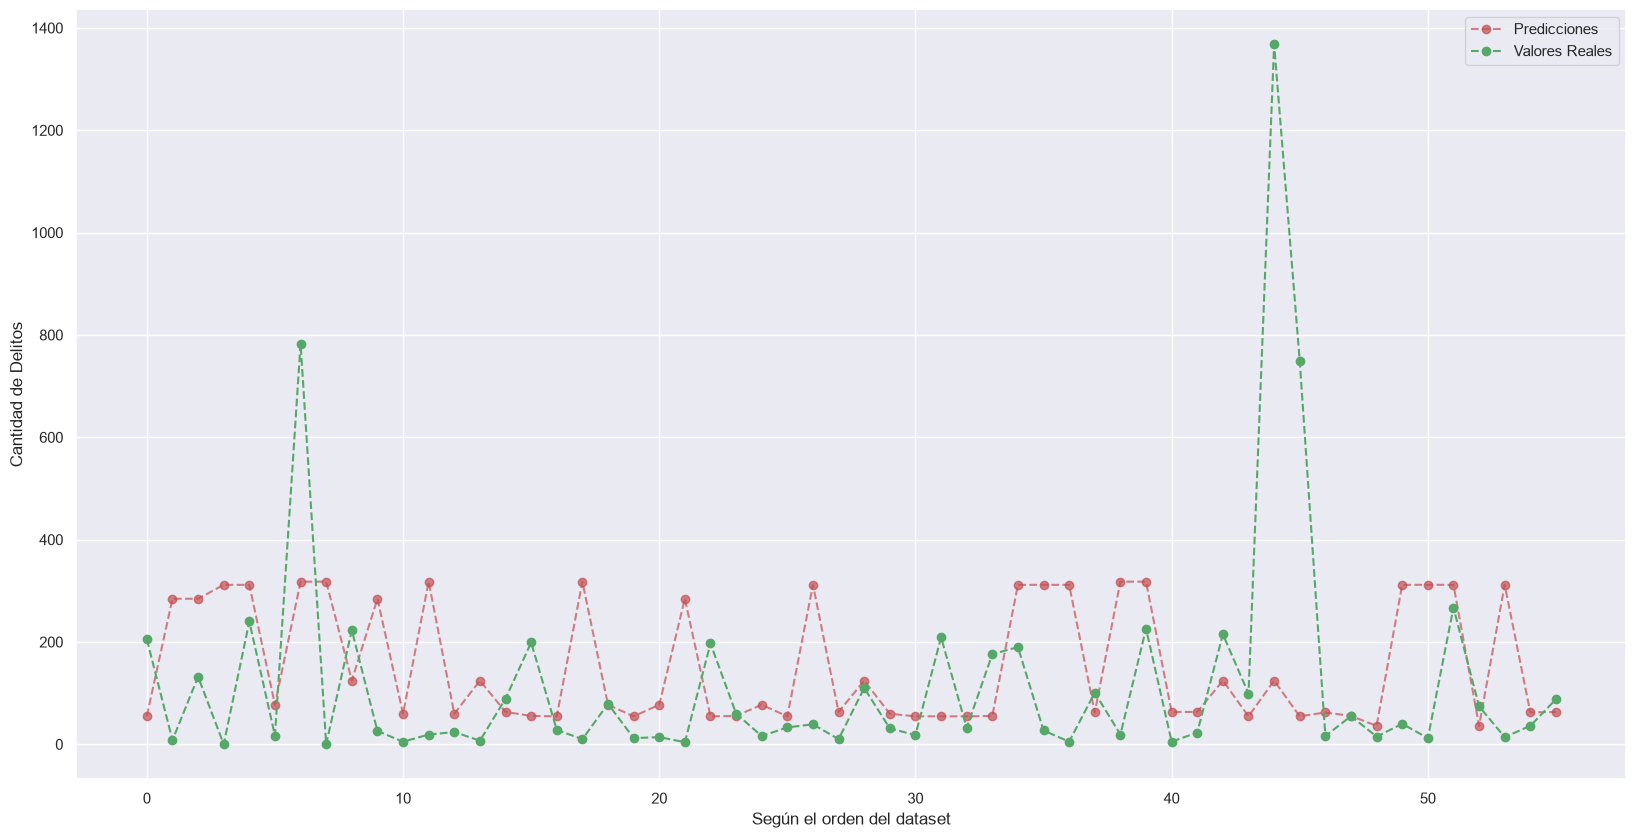

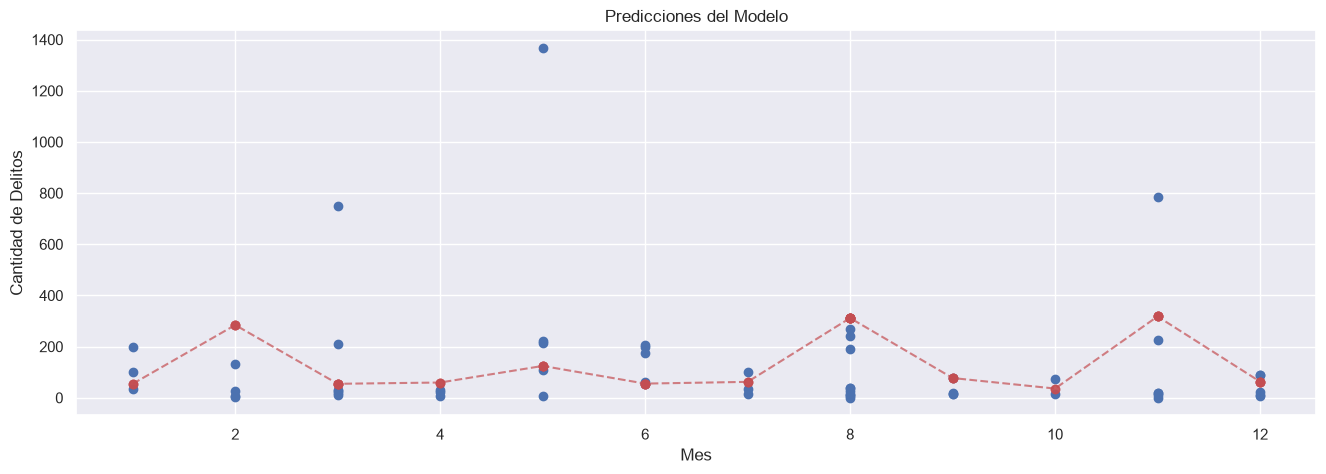

In [36]:
from sklearn.neighbors import KNeighborsRegressor

print("Probando el Modelo KNN")
probar_modelo(KNeighborsRegressor(), X_train, y_train, X_test, y_test)

Probando el Modelo GBR
Rendimiento del conjunto de Entrenamiento
RMSE: 306.83088859340654
R2: 0.011905814309851603
Rendimiento del conjunto de Testeo
RMSE: 247.14093647205726
R2: -0.20067631124576013


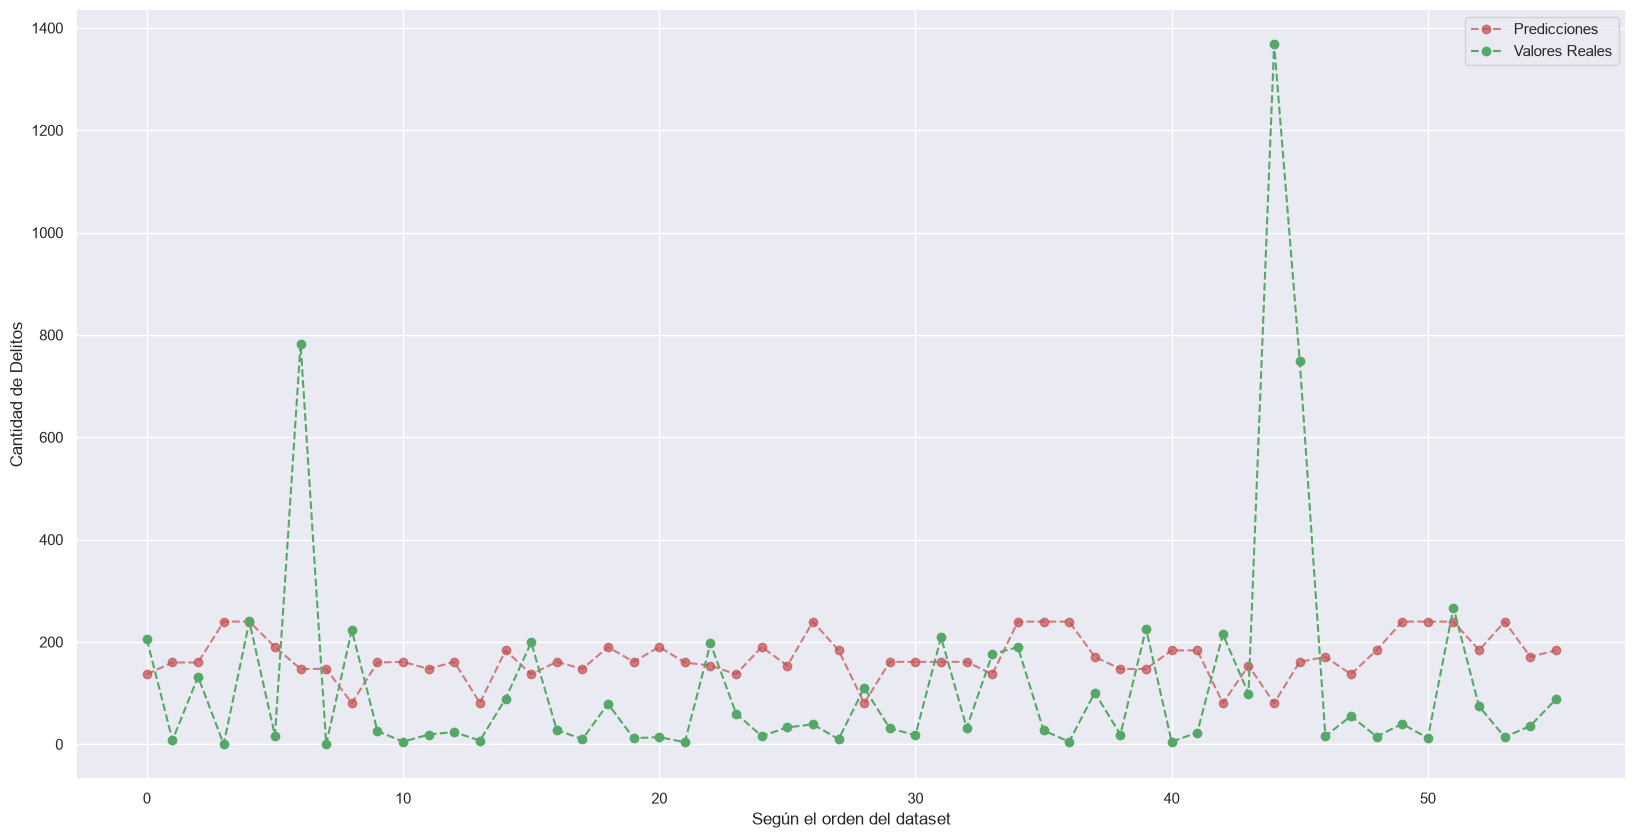

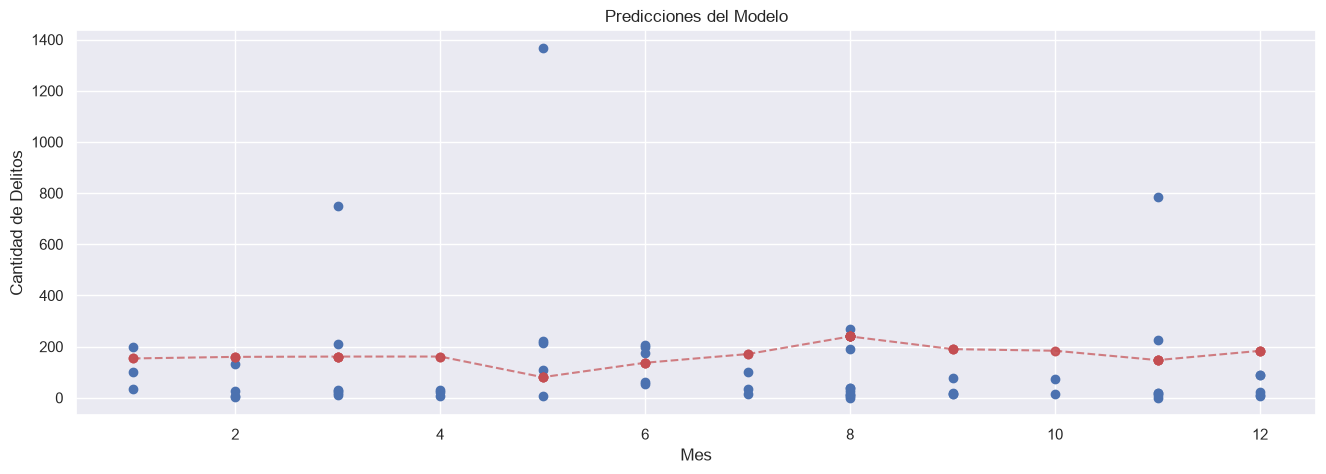

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

print("Probando el Modelo GBR")
probar_modelo(GradientBoostingRegressor(), X_train, y_train, X_test, y_test)

Probando el Modelo Ada
Rendimiento del conjunto de Entrenamiento
RMSE: 309.7707534033982
R2: -0.0071195168456557045
Rendimiento del conjunto de Testeo
RMSE: 243.83086120426717
R2: -0.1687292450369171


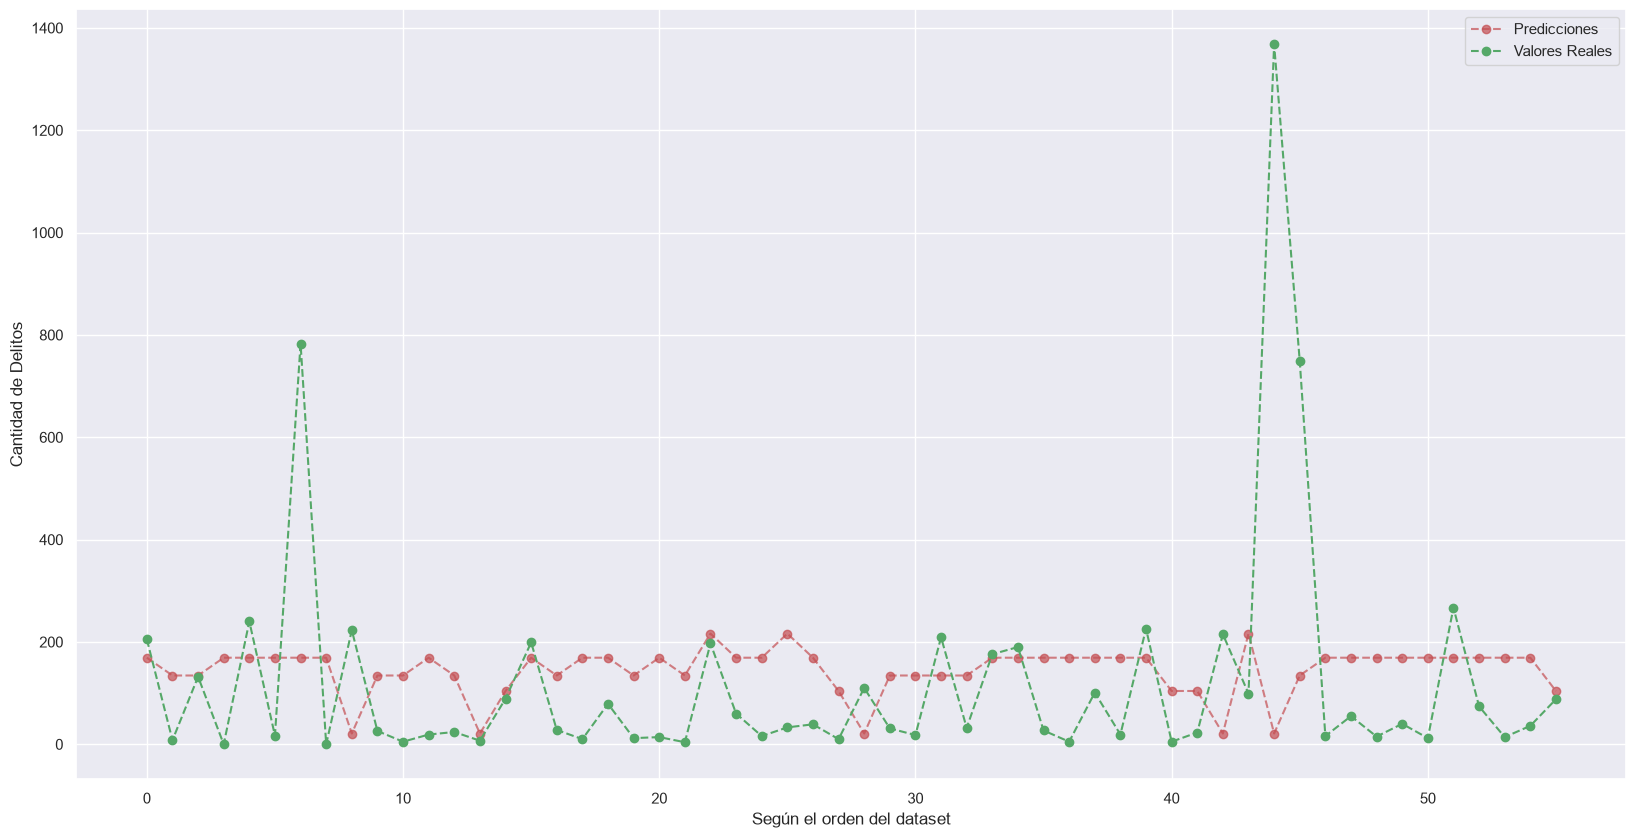

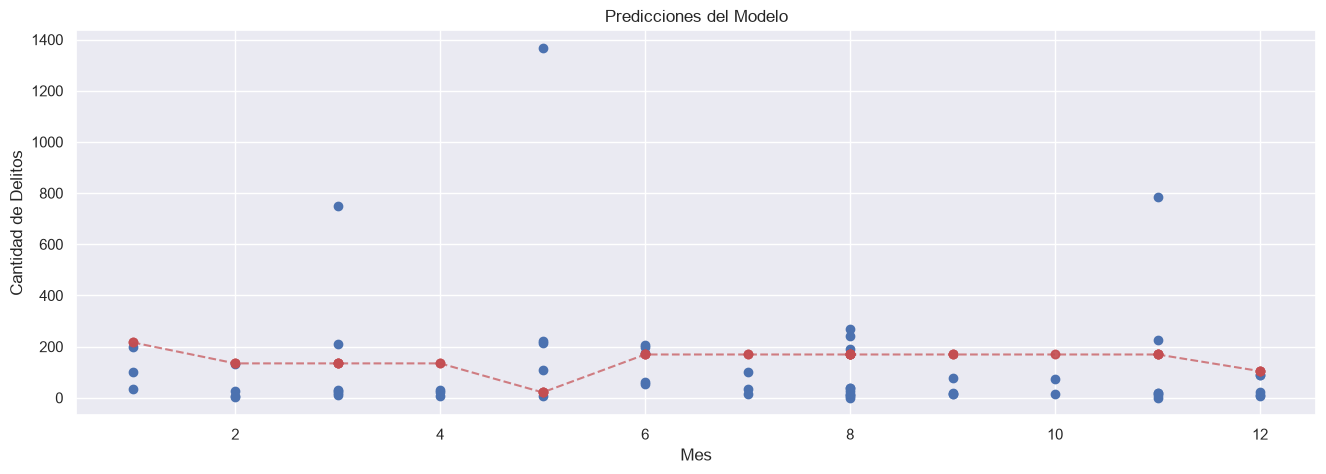

In [38]:
from sklearn.ensemble import AdaBoostRegressor

print("Probando el Modelo Ada")
probar_modelo(AdaBoostRegressor(), X_train, y_train, X_test, y_test)

In [39]:
# Validación cruzada entre los modelos
from sklearn.model_selection import cross_val_score

modelos = {}
modelos['LR_'] = LinearRegression()
modelos['Las'] = Lasso()
modelos['SVM'] = SVR()
modelos['DTR'] = DecisionTreeRegressor()
modelos['KNN'] = KNeighborsRegressor()
modelos['GBR'] = GradientBoostingRegressor()
modelos['Ada'] = AdaBoostRegressor()

resultados_modelos = []

print("Modelos\t\t Mean \t\t Std")

for modelo_a_probar in modelos:
    resultados = cross_val_score(modelos[modelo_a_probar], X_train, y_train,
                                  scoring='neg_mean_squared_error')
    resultados_modelos.append(resultados)
    print("{}\t\t: {}\t {}".format(modelo_a_probar,
                                   round(resultados.mean(), 3),
                                   round(resultados.std(), 3)))

Modelos		 Mean 		 Std
LR_		: -96260.733	 40354.445
Las		: -96260.464	 40356.671
SVM		: -110753.925	 48535.045
DTR		: -106866.202	 47093.115
KNN		: -119957.466	 47650.184
GBR		: -106819.483	 47072.26
Ada		: -113349.03	 47393.762


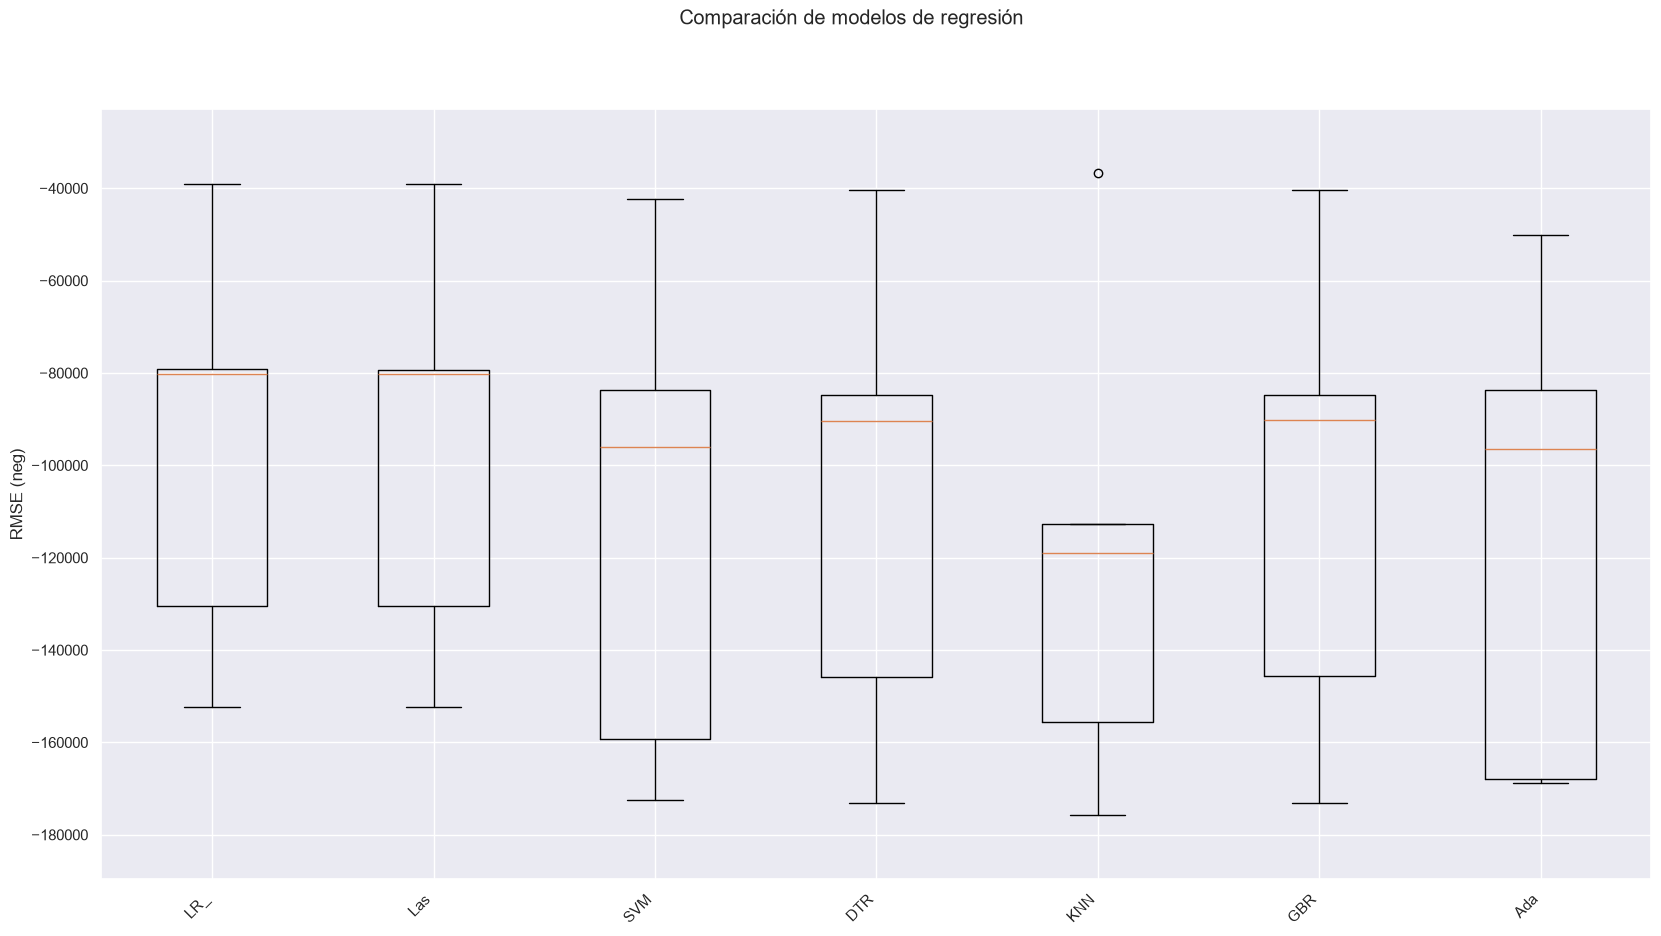

In [40]:
# Graficar la comparación con velas/cajas
figura = plt.figure()
figura.suptitle('Comparación de modelos de regresión')
ejes = figura.add_subplot(111)

plt.boxplot(resultados_modelos)
ejes.set_xticklabels(modelos, rotation=45, ha="right")
ejes.set_ylabel("RMSE (neg)")
plt.margins(0.05, 0.1)
plt.show()